In [1]:
# setup
from mlwpy import *
diabetes = datasets.load_diabetes()
%matplotlib inline

In [2]:
N = 20
ftr = np.linspace(-10, 10, num=N) # ftr values
tgt = 2*ftr**2 - 3 + np.random.uniform(-2, 2, N) # tgt = func(ftr)
(train_ftr, test_ftr,
train_tgt, test_tgt) = skms.train_test_split(ftr, tgt, test_size=N//2)
display(pd.DataFrame({"ftr":train_ftr,
"tgt":train_tgt}).T)

,0,1,2,3,4,5,6,7,8,9
ftr,-1.5789,-6.8421,-3.6842,1.5789,-7.8947,3.6842,7.8947,4.7368,5.7895,-0.5263
tgt,2.3906,91.0234,22.3791,3.8658,122.5817,22.9962,121.7528,40.6026,62.7696,-1.6137


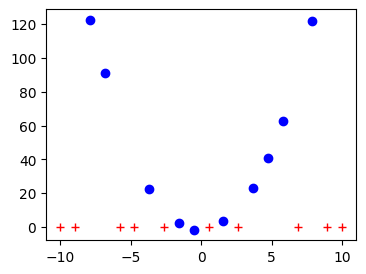

In [3]:
plt.plot(train_ftr, train_tgt, 'bo')
plt.plot(test_ftr, np.zeros_like(test_ftr), 'r+');

In [5]:
# note: sklearn *really* wants 2D inputs (a table)
# so we use rehape here.
sk_model = linear_model.LinearRegression()
sk_model.fit(train_ftr.reshape(-1, 1), train_tgt)
sk_preds = sk_model.predict(test_ftr.reshape(-1, 1))
sk_preds[:3]

array([53.218 , 41.4552, 56.8374])

In [6]:
# fit-predict-evaluate a 1D polynomial (a line)
model_one = np.poly1d(np.polyfit(train_ftr, train_tgt, 1))
preds_one = model_one(test_ftr)
print(preds_one[:3])

[53.218  41.4552 56.8374]


In [7]:
# the predictions come back the same
print("all close?", np.allclose(sk_preds, preds_one))
# and we can still use sklearn to evaluate it
mse = metrics.mean_squared_error
print("RMSE:", np.sqrt(mse(test_tgt, preds_one)))

all close? True
RMSE: 86.69151817350722


In [8]:
# fit-predict-evaluate a 2D polynomial (a parabola)
model_two = np.poly1d(np.polyfit(train_ftr, train_tgt, 2))
preds_two = model_two(test_ftr)
print("RMSE:", np.sqrt(mse(test_tgt, preds_two)))

RMSE: 1.2765992188881128


In [9]:
model_three = np.poly1d(np.polyfit(train_ftr, train_tgt, 9))
preds_three = model_three(test_ftr)
print("RMSE:", np.sqrt(mse(test_tgt, preds_three)))

RMSE: 317.36344242355176


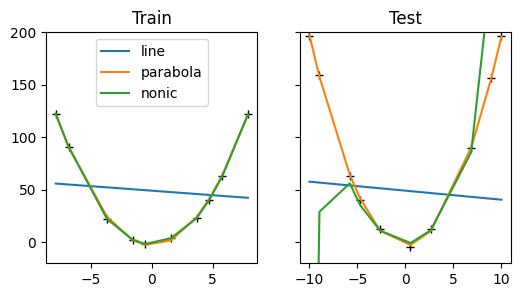

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

labels = ['line', 'parabola', 'nonic']
models = [model_one, model_two, model_three]

train = (train_ftr, train_tgt)
test = (test_ftr, test_tgt)

for ax, (ftr, tgt) in zip(axes, [train, test]):
    ax.plot(ftr, tgt, 'k+')
    for m, lbl in zip(models, labels):
        sorted_ftr = sorted(ftr)
        ax.plot(sorted_ftr, m(sorted_ftr), '-', label=lbl)

axes[1].set_ylim(-20, 200)
axes[0].set_title("Train")
axes[1].set_title("Test")
axes[0].legend(loc='upper center')


In [12]:
results = []

for complexity in [1, 2, 6, 9]:
    model = np.poly1d(np.polyfit(train_ftr, train_tgt, complexity))
    train_error = np.sqrt(mse(train_tgt, model(train_ftr)))
    test_error = np.sqrt(mse(test_tgt, model(test_ftr)))
    results.append((complexity, train_error, test_error))

columns = ["Complexity", "Train Error", "Test Error"]
results_df = pd.DataFrame.from_records(results, columns=columns, index="Complexity")
results_df


,Train Error,Test Error
Complexity,,
1,45.4951,86.6915
2,1.0828,1.2766
6,0.2819,6.1417
9,0.0000,317.3634


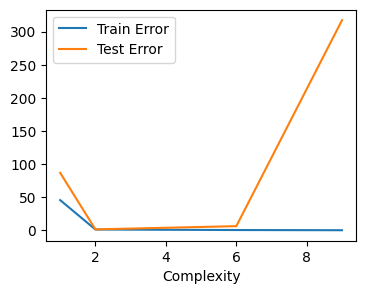

In [13]:
results_df.plot();

In [15]:
def training_loss(loss, model, training_data):
    """Total training loss on training_data using the model and loss function."""
    return sum(
        loss(model.predict(x.reshape(1, -1)), y)
        for x, y in training_data
    )

def squared_error(prediction, actual):
    """Squared error on a single example."""
    return (prediction - actual) ** 2

# Example usage:
# my_training_loss = training_loss(squared_error, model, training_data)


In [16]:
knn = neighbors.KNeighborsRegressor(n_neighbors=3)
fit = knn.fit(diabetes.data, diabetes.target)
training_data = zip(diabetes.data, diabetes.target)
my_training_loss = training_loss(squared_error,
knn,
training_data)
print(my_training_loss)

[863792.3333]


In [17]:
mse = metrics.mean_squared_error(diabetes.target,
knn.predict(diabetes.data))
print(mse*len(diabetes.data))

863792.3333333333


In [18]:
def complexity(model):
    return model.complexity
def cost(model, training_data, loss, _lambda):
    return training_loss(m,D) + _lambda * complexity(m)

In [19]:
# data, model, fit & cv-score
model = neighbors.KNeighborsRegressor(10)
skms.cross_val_score(model,
diabetes.data,
diabetes.target,
cv=5,
scoring='neg_mean_squared_error')
# notes:
# defaults for cross_val_score are
# cv=3 fold, no shuffle, stratified if classifier
# model.score by default (regressors: r2, classifiers: accuracy)

array([-3206.7542, -3426.4313, -3587.9422, -3039.4944, -3282.6016])

In [20]:
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(10)
skms.cross_val_score(model, iris.data, iris.target, cv=5)

array([0.9667, 1.    , 1.    , 0.9333, 1.    ])

In [21]:
# not stratified
pet = np.array(['cat', 'dog', 'cat',
'dog', 'dog', 'dog'])
list_folds = list(skms.KFold(2).split(pet))
training_idxs = np.array(list_folds)[:, 0, :]
print(pet[training_idxs])

[['dog' 'dog' 'dog']
 ['cat' 'dog' 'cat']]


In [22]:
# Stratified split demonstration
import numpy as np
from sklearn import model_selection as skms

# Example categorical labels
pet = np.array(['cat', 'dog', 'cat', 'dog', 'dog', 'dog'])

# Generate indices using StratifiedKFold
idxs = np.array(list(skms.StratifiedKFold(n_splits=2).split(np.ones_like(pet), pet)))

# Get training indices for each fold
training_idxs = idxs[:, 0, :]

# Show the class distribution in each training fold
print(pet[training_idxs])


[['cat' 'dog' 'dog']
 ['cat' 'dog' 'dog']]


In [23]:
# running nonstratified CV
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(10)
non_strat_kf = skms.KFold(5)
skms.cross_val_score(model,
iris.data,
iris.target,
cv=non_strat_kf)

array([1.    , 1.    , 0.8667, 0.9667, 0.7667])

In [26]:
# Assumes these are available via: from mlwpy import *
# from sklearn import (datasets, neighbors, model_selection as skms,
#                      linear_model, metrics)
# Also assumes np and pd are available via mlwpy

linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
scores = []

for r in range(10):
    tts = skms.train_test_split(diabetes.data, diabetes.target, test_size=0.25)
    diabetes_train_ftrs, diabetes_test_ftrs, diabetes_train_tgt, diabetes_test_tgt = tts

    fit = linreg.fit(diabetes_train_ftrs, diabetes_train_tgt)
    preds = fit.predict(diabetes_test_ftrs)
    score = metrics.mean_squared_error(diabetes_test_tgt, preds)
    scores.append(score)

# Convert to RMSE and sort
scores = pd.Series(np.sqrt(sorted(scores)))
df = pd.DataFrame({'RMSE': scores})
df.index.name = 'Repeat'
display(df.T)


Repeat,0,1,2,3,4,5,6,7,8,9
RMSE,49.0031,50.1913,51.9735,52.0722,53.2003,55.7007,56.2542,57.4919,58.6383,58.6942


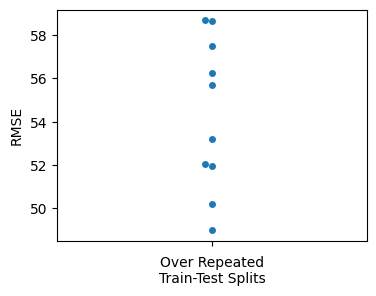

In [27]:
ax = plt.figure(figsize=(4, 3)).gca()
sns.swarmplot(y='RMSE', data=df, ax=ax)
ax.set_xlabel('Over Repeated\nTrain-Test Splits');

In [28]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
RMSE,10.0000,54.3220,3.5059,49.0031,51.9982,54.4505,57.1825,58.6942


In [29]:
def tts_fit_score(model, data, msr, test_size=.25):
    ' apply a train-test split to fit model on data and eval with MSR '
    tts = skms.train_test_split(data.data,
                                data.target,
                                test_size=test_size)
    (train_ftrs, test_ftrs, train_tgt, test_tgt) = tts
    fit = linreg.fit(train_ftrs, train_tgt)
    preds = fit.predict(test_ftrs)
    score = msr(test_tgt, preds)
    return score

linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
scores = [tts_fit_score(linreg, diabetes,
                        metrics.mean_squared_error) for i in range(10)]
print(np.mean(scores))


3052.548205801788


,count,mean,std,min,25%,50%,75%,max
RMSE,10.0000,55.9133,2.9062,53.0500,54.0688,54.8888,56.8317,62.6032


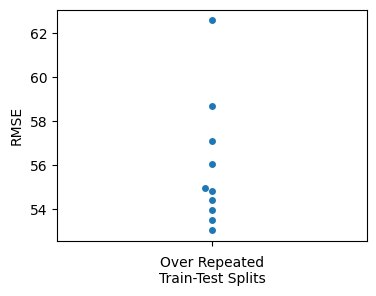

In [31]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
# nondefault cv= argument
ss = skms.ShuffleSplit(test_size=.25) # default, 10 splits
scores = skms.cross_val_score(linreg,
diabetes.data, diabetes.target,
cv=ss,
scoring='neg_mean_squared_error')
scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.describe().T)
ax = sns.swarmplot(y='RMSE', data=df)
ax.set_xlabel('Over Repeated\nTrain-Test Splits');

In [32]:
ss = skms.ShuffleSplit(test_size=.25, random_state=42)
train, test = 0, 1
next(ss.split(diabetes.data))[train][:10]

array([ 16, 408, 432, 316,   3,  18, 355,  60, 398, 124], dtype=int32)

In [33]:
ss = skms.ShuffleSplit(test_size=.25, random_state=42)
next(ss.split(diabetes.data))[train][:10]

array([ 16, 408, 432, 316,   3,  18, 355,  60, 398, 124], dtype=int32)

In [34]:
train, test = 0, 1
kf = skms.KFold(5)
next(kf.split(diabetes.data))[train][:10]

array([89, 90, 91, 92, 93, 94, 95, 96, 97, 98])

In [35]:
kf = skms.KFold(5)
next(kf.split(diabetes.data))[train][:10]

array([89, 90, 91, 92, 93, 94, 95, 96, 97, 98])

In [36]:
pet = np.array(['cat', 'dog', 'cat',
'dog', 'dog', 'dog'])
kf = skms.KFold(3, shuffle=True)
train, test = 0, 1
split_1_group_1 = next(kf.split(pet))[train]
split_2_group_1 = next(kf.split(pet))[train]
print(split_1_group_1,
split_2_group_1)

[0 1 2 4] [0 1 2 3]


In [37]:
kf = skms.KFold(3, shuffle=True, random_state=42)
split_1_group_1 = next(kf.split(pet))[train]
split_2_group_1 = next(kf.split(pet))[train]
print(split_1_group_1,
split_2_group_1)

[2 3 4 5] [2 3 4 5]


,count,mean,std,min,25%,50%,75%,max
RMSE,442.0000,44.3557,32.1973,0.2086,18.4853,39.5482,63.9743,158.2330


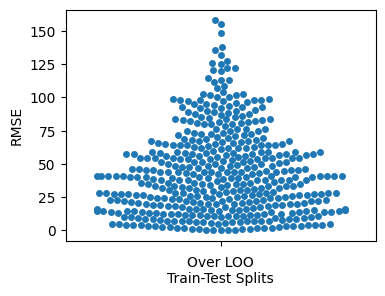

In [38]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
loo = skms.LeaveOneOut()
scores = skms.cross_val_score(linreg,
diabetes.data, diabetes.target,
cv=loo,
scoring='neg_mean_squared_error')
scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.describe().T)
ax = sns.swarmplot(y='RMSE', data=df)
ax.set_xlabel('Over LOO\nTrain-Test Splits');

In [40]:
iris = datasets.load_iris()

# 10 dataset sizes: 10% to 100% of data
train_sizes = np.linspace(0.1, 1.0, 10)

nn = neighbors.KNeighborsClassifier()

(train_N, train_scores, test_scores) = skms.learning_curve(
    nn, iris.data, iris.target, cv=5, train_sizes=train_sizes
)

# Collapse across the 5 CV scores; one result for each dataset size
df = pd.DataFrame(test_scores, index=(train_sizes * 100).astype(np.int64))
df['Mean 5-CV'] = df.mean(axis='columns')
df.index.name = "% Data Used"

display(df)


,0,1,2,3,4,Mean 5-CV
% Data Used,,,,,,
10,0.3333,0.3333,0.3333,0.3333,0.3333,0.3333
20,0.3333,0.3333,0.3333,0.3333,0.3333,0.3333
30,0.3333,0.3333,0.3333,0.3333,0.3333,0.3333
40,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667
50,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667
60,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667
70,0.9333,0.8000,0.8333,0.8667,0.8000,0.8467
80,0.9667,0.9333,0.9000,0.9000,0.9667,0.9333
90,0.9667,1.0000,0.9000,0.9667,1.0000,0.9667


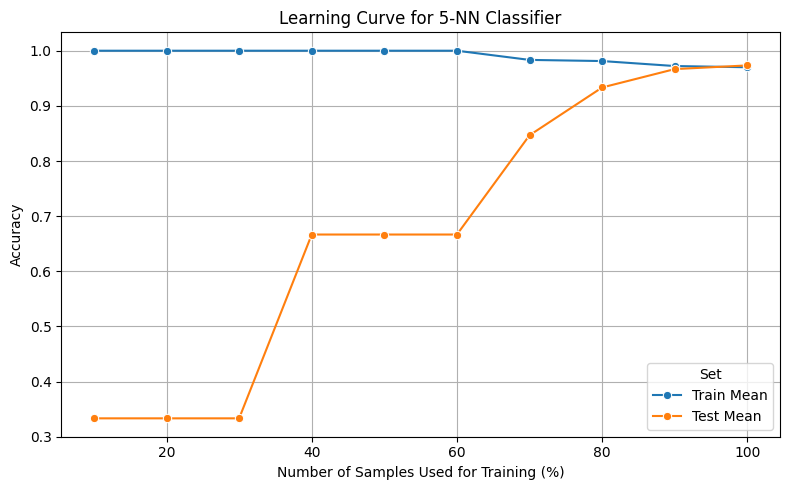

In [42]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame with appropriate structure
df = pd.DataFrame({
    "Train Size (%)": (train_sizes * 100).astype(int),
    "Train Mean": train_scores.mean(axis=1),
    "Test Mean": test_scores.mean(axis=1)
})

# Melt the DataFrame to long-form for seaborn
df_long = df.melt(id_vars="Train Size (%)",
                  value_vars=["Train Mean", "Test Mean"],
                  var_name="Set",
                  value_name="Accuracy")

# Plot
plt.figure(figsize=(8, 5))
ax = sns.lineplot(data=df_long, x="Train Size (%)", y="Accuracy", hue="Set", marker="o")
ax.set_title("Learning Curve for 5-NN Classifier")
ax.set_xlabel("Number of Samples Used for Training (%)")
ax.set_ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


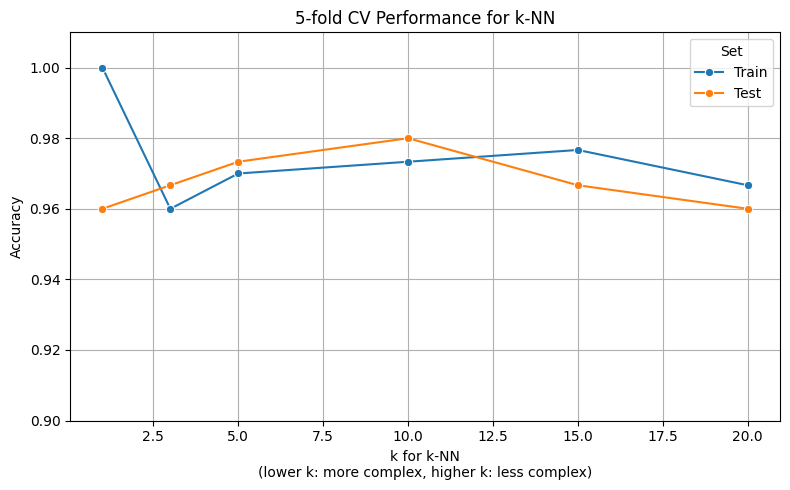

In [46]:
num_neigh = [1, 3, 5, 10, 15, 20]
KNC = neighbors.KNeighborsClassifier

# Run validation curve
train_scores, test_scores = skms.validation_curve(
    KNC(), iris.data, iris.target,
    param_name='n_neighbors',
    param_range=num_neigh,
    cv=5
)

# Compute means
train_means = train_scores.mean(axis=1)
test_means = test_scores.mean(axis=1)

# Prepare DataFrame for plotting
df = pd.DataFrame({
    'k': num_neigh,
    'Train': train_means,
    'Test': test_means
})

df_long = df.melt(id_vars='k', value_vars=['Train', 'Test'],
                  var_name='Set', value_name='Accuracy')

# Plot
plt.figure(figsize=(8, 5))
ax = sns.lineplot(data=df_long, x='k', y='Accuracy', hue='Set', marker='o')
ax.set_title('5-fold CV Performance for k-NN')
ax.set_xlabel("k for k-NN\n(lower k: more complex, higher k: less complex)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.9, 1.01)
plt.grid(True)
plt.tight_layout()
plt.show()

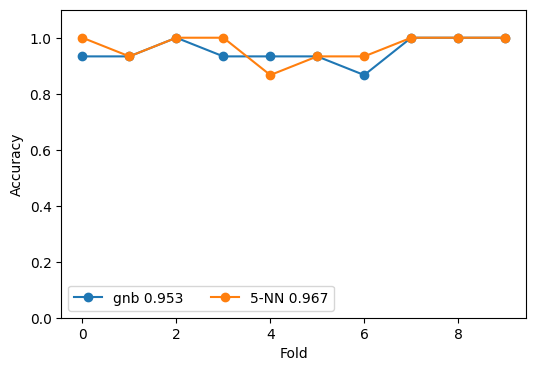

In [47]:
classifiers = {
    'gnb': naive_bayes.GaussianNB(),
    '5-NN': neighbors.KNeighborsClassifier(n_neighbors=5)
}

iris = datasets.load_iris()
fig, ax = plt.subplots(figsize=(6, 4))

for name, model in classifiers.items():
    cv_scores = skms.cross_val_score(
        model,
        iris.data, iris.target,
        cv=10,
        scoring='accuracy',
        n_jobs=-1  # use all cores
    )
    my_lbl = "{} {:.3f}".format(name, cv_scores.mean())
    ax.plot(cv_scores, '-o', label=my_lbl)  # marker=next(markers)

ax.set_ylim(0.0, 1.1)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend(ncol=2)
